# Fed rate decisions — next 6 months
### Polymarket implied probabilities

Pulls FOMC-decision markets from the Polymarket Gamma API.  
Where several markets describe the same meeting we keep only the deepest (max liquidity) to cut noise, then pull sibling markets to get the full probability distribution over rate outcomes.

In [1]:
import re

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

from alpha_lab.data.loaders.polymarket import (
    implied_prob,
    search_events,
    search_markets,
    tidy,
    top_by_liquidity,
)

HORIZON_MONTHS = 6
NOW = pd.Timestamp.utcnow()
HORIZON_END = NOW + pd.DateOffset(months=HORIZON_MONTHS)

## 1. Discover & deduplicate markets

Cast a wide net across FOMC-related phrasing, deduplicate by market id, and filter to the 6-month horizon.

In [2]:
queries = ["fed decision", "fed rate", "fomc"]
frames = [search_markets(q, limit=200) for q in queries]
markets = (
    pd.concat(frames, ignore_index=True)
    .drop_duplicates(subset=["id"])
)
markets = markets[markets["endDate"].between(NOW, HORIZON_END)]

# Keep only markets whose question explicitly mentions the Fed/FOMC
markets = markets[
    markets["question"].str.contains(r"\b(?:fed|fomc|federal reserve)\b", flags=re.I, na=False)
]
len(markets)

4

## 2. Selected market per FOMC meeting

One row per upcoming meeting — the single deepest market by liquidity.

In [3]:
markets["meeting"] = markets["endDate"].dt.strftime("%Y-%m")
per_meeting = (
    markets.sort_values("liquidityNum", ascending=False)
    .groupby("meeting", sort=False)
    .first()
    .reset_index()
    .sort_values("endDate")
)

(
    tidy(per_meeting)
    .style
    .format({
        "yes": "{:.1%}",
        "liquidityNum": "${:,.0f}",
        "volumeNum": "${:,.0f}",
        "endDate": lambda t: t.strftime("%b %d, %Y"),
    })
    .bar(subset=["yes"], color="#a8d5a2", vmin=0, vmax=1)
    .set_caption("Selected market per FOMC meeting (deepest by liquidity)")
)

,question,endDate,yes,liquidityNum,volumeNum,slug
0,Will the Fed decrease interest rates by 50+ bps after the April 2026 meeting?,"Apr 29, 2026",0.1%,"$10,191,607","$46,918,068",will-the-fed-decrease-interest-rates-by-50-bps-after-the-april-2026-meeting


## 3. Rate-outcome probability distribution

For each selected meeting, pull all sibling markets from the same Polymarket event to get the full distribution across rate-change outcomes.

In [4]:
_FED_EV_PAT = r"\b(?:fed|fomc|federal reserve|rate decision)\b"

dists = []
seen_events: set = set()

for _, mkt_row in per_meeting.iterrows():
    slug = (
        mkt_row["eventSlug"]
        if "eventSlug" in per_meeting.columns and pd.notna(mkt_row.get("eventSlug"))
        else None
    )
    query = slug or mkt_row["question"][:60]

    ev = search_events(query=query, limit=10)
    if ev.empty:
        continue

    # search_events returns top-liquidity events regardless of query — filter by title
    ev = ev[ev["title"].str.contains(_FED_EV_PAT, flags=re.I, na=False)]
    if ev.empty:
        continue

    row = ev.iloc[0]
    event_id = row.get("id") or row.get("slug")
    if event_id in seen_events:
        continue
    seen_events.add(event_id)

    children = pd.DataFrame(row.get("markets") or [])
    if children.empty:
        continue
    children = children.assign(
        event=row.get("title"),
        yes=children.apply(lambda r: implied_prob(r.to_dict(), "Yes"), axis=1),
    )
    want = ["event", "question", "yes", "liquidityNum", "volumeNum"]
    dists.append(children[[c for c in want if c in children.columns]])

distribution = pd.concat(dists, ignore_index=True) if dists else pd.DataFrame()

if not distribution.empty:
    display(
        distribution
        .sort_values(
            ["event", "liquidityNum"] if "liquidityNum" in distribution.columns else ["event"],
            ascending=[True, False] if "liquidityNum" in distribution.columns else [True],
        )
        .style
        .format({
            "yes": "{:.1%}",
            **({} if "liquidityNum" not in distribution.columns else {"liquidityNum": "${:,.0f}"}),
            **({} if "volumeNum" not in distribution.columns else {"volumeNum": "${:,.0f}"}),
        })
        .bar(subset=["yes"], color="#a8d5a2", vmin=0, vmax=1)
        .set_caption("Rate-outcome distribution by meeting")
    )

,event,question,yes,liquidityNum,volumeNum
0,Fed decision in April?,Will the Fed decrease interest rates by 50+ bps after the April 2026 meeting?,0.1%,"$10,191,607","$46,918,068"
3,Fed decision in April?,Will the Fed increase interest rates by 25+ bps after the April 2026 meeting?,0.2%,"$3,291,811","$33,678,978"
2,Fed decision in April?,Will there be no change in Fed interest rates after the April 2026 meeting?,99.5%,"$2,934,597","$28,861,542"
1,Fed decision in April?,Will the Fed decrease interest rates by 25 bps after the April 2026 meeting?,0.2%,"$1,975,213","$27,127,961"


## 4. Implied-probability chart

Stacked horizontal bars — one row per FOMC meeting, width proportional to market-implied probability.  
Color: **green** = rate cuts · **gray** = hold · **red** = rate hikes.

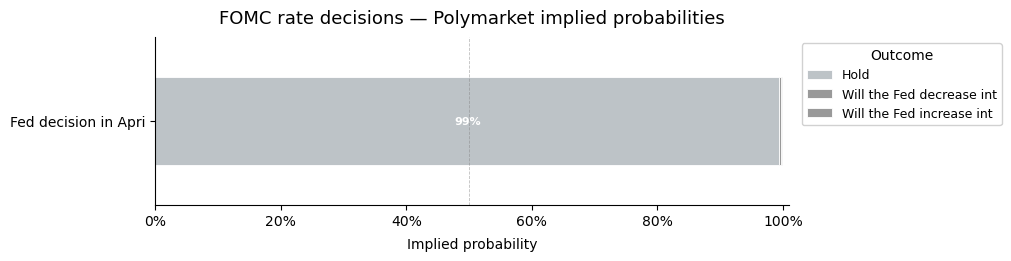

In [5]:
_PATTERNS = [
    (r"\bcut.{0,8}75\b",                       "Cut ≥75bp"),
    (r"\bcut.{0,8}50\b",                        "Cut 50bp"),
    (r"\bcut.{0,8}25\b",                        "Cut 25bp"),
    (r"\b(hold|unchanged|no.change|pause)\b",   "Hold"),
    (r"\b(hike|raise).{0,8}25\b",              "Hike 25bp"),
    (r"\b(hike|raise).{0,8}50\b",              "Hike ≥50bp"),
]

_COLOR_MAP = {
    "Cut ≥75bp": "#1a9641",
    "Cut 50bp":  "#2ecc71",
    "Cut 25bp":  "#a8d5a2",
    "Hold":      "#bdc3c7",
    "Hike 25bp": "#f0a899",
    "Hike ≥50bp":"#e74c3c",
}

_OUTCOME_ORDER = list(_COLOR_MAP)


def _short_label(question: str) -> str:
    q = question.lower()
    for pat, label in _PATTERNS:
        if re.search(pat, q):
            return label
    return question[:25]


if distribution.empty or "yes" not in distribution.columns:
    print("No distribution data — skipping chart")
else:
    dist = distribution.dropna(subset=["yes"]).copy()
    if dist.empty:
        print("All yes-probabilities are None — skipping chart")
    else:
        dist["outcome"] = dist["question"].apply(_short_label)
        dist["meeting"] = (
            dist["event"].str.extract(r"(\w+\s+\d{4})", expand=False)
            .fillna(dist["event"].str[:20])
        )

        pivot = (
            dist.groupby(["meeting", "outcome"])["yes"]
            .mean()
            .unstack("outcome")
            .fillna(0)
        )

        if pivot.empty or not pivot.select_dtypes("number").shape[1]:
            print("Could not build pivot — check distribution data")
        else:
            cols_ordered = [c for c in _OUTCOME_ORDER if c in pivot.columns]
            cols_other   = [c for c in pivot.columns if c not in _OUTCOME_ORDER]
            pivot = pivot[cols_ordered + cols_other]
            colors = [_COLOR_MAP.get(c, "#999999") for c in pivot.columns]

            fig, ax = plt.subplots(
                figsize=(10, max(2.5, len(pivot) * 1.1)),
                constrained_layout=True,
            )
            pivot.plot(kind="barh", stacked=True, ax=ax, color=colors, width=0.55,
                       edgecolor="white", linewidth=0.6)

            for patch in ax.patches:
                w = patch.get_width()
                if w > 0.035:
                    x_mid = patch.get_x() + w / 2
                    y_mid = patch.get_y() + patch.get_height() / 2
                    fg = "white" if w > 0.12 else "#333333"
                    ax.text(x_mid, y_mid, f"{w:.0%}", ha="center", va="center",
                            fontsize=8, color=fg, fontweight="bold")

            ax.set_xlabel("Implied probability", labelpad=6)
            ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
            ax.set_xlim(0, 1.01)
            ax.set_ylabel("")
            ax.set_title("FOMC rate decisions — Polymarket implied probabilities", fontsize=13, pad=10)
            ax.axvline(0.5, color="gray", linewidth=0.6, linestyle="--", alpha=0.5)
            ax.legend(title="Outcome", bbox_to_anchor=(1.01, 1), loc="upper left",
                      framealpha=0.9, fontsize=9)
            ax.spines[["top", "right"]].set_visible(False)
            plt.show()

## 5. TLT price trajectory

Trailing 12 months of TLT (20+ Year Treasury Bond ETF) with upcoming FOMC meeting dates marked. Rising TLT = falling long-end rates; falling TLT = rising rates. Useful context for whether the market is pricing cuts/hikes before they happen.

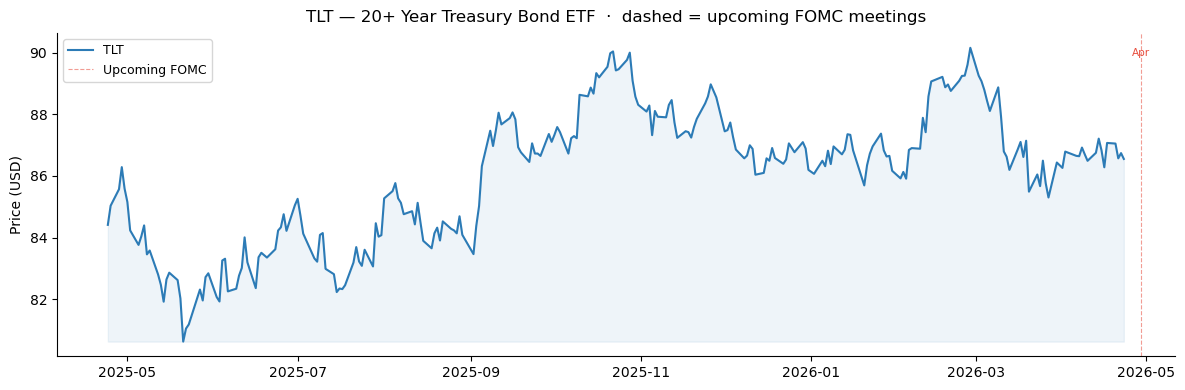

In [6]:
from alpha_lab.data.loaders.yfinance import load_prices

TLT_LOOKBACK_MONTHS = 12
tlt_start = (NOW - pd.DateOffset(months=TLT_LOOKBACK_MONTHS)).strftime("%Y-%m-%d")
tlt = load_prices("TLT", start=tlt_start)

# FOMC meeting dates — strip tz so they align with yfinance's tz-naive index
fomc_dates = pd.to_datetime(per_meeting["endDate"].dt.date)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tlt.index, tlt["TLT"], color="#2c7bb6", linewidth=1.5, label="TLT")
ax.fill_between(tlt.index, tlt["TLT"], tlt["TLT"].min(), alpha=0.08, color="#2c7bb6")

price_max = tlt["TLT"].max()
for i, dt in enumerate(fomc_dates):
    label = "Upcoming FOMC" if i == 0 else None
    ax.axvline(dt, color="#e74c3c", linewidth=0.8, linestyle="--", alpha=0.55, label=label)
    ax.text(dt, price_max, dt.strftime("%b"), ha="center",
            fontsize=7.5, color="#e74c3c", va="top")

ax.set_ylabel("Price (USD)")
ax.set_title("TLT — 20+ Year Treasury Bond ETF  ·  dashed = upcoming FOMC meetings",
             fontsize=12, pad=8)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()